# Speech Emotion Recognition — Publication-Quality Benchmark
**Datasets:** RAVDESS + CREMA-D  
**Emotions:** angry · disgust · fearful · happy · neutral · sad  
**Models:** SVM · CNN1D+Att+BiLSTM · CNN2D+Att+BiLSTM · PANNs · Wav2Vec2  
**Split:** Dataset-Stratified Speaker-Independent 70/15/15  

---
## Mandatory Execution Order
```
Phase 1  → Load Datasets
Phase 2  → Emotion Mapping
Phase 3  → Merge Datasets
Phase 4  → EDA
Phase 5  → Audio Preprocessing + Feature Extraction
Phase 6  → Save Raw Cache
Phase 7  → Dataset-Stratified Speaker Split
Phase 8  → Compute Train Statistics (LogMel only)
Phase 9  → Apply Global Normalization
Phase 10 → Create Datasets + DataLoaders
Phase 11 → SVM
Phase 12 → CNN1D + Attention + BiLSTM
Phase 13 → CNN2D + Attention + BiLSTM
Phase 14 → PANNs
Phase 15 → Wav2Vec2
Phase 16 → Final Benchmark
Phase 17 → Discussion + Limitations
```

---
## Cell 0 — Install & Import Dependencies

In [1]:
# ── Install (run once, then restart kernel if needed) ──────────────────────
# !pip install librosa soundfile transformers tqdm seaborn scikit-learn torch torchvision

In [2]:
# ── Standard library ───────────────────────────────────────────────────────
import os
import glob
import json
import time
import random
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

# ── Third-party ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import librosa
import librosa.display

from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    recall_score, precision_score, classification_report
)
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# ── Wav2Vec2 ───────────────────────────────────────────────────────────────
try:
    from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor
    TRANSFORMERS_AVAILABLE = True
    print("✅ Transformers available")
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    print(f"⚠️  Transformers not available: {e}")

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print("✅ All imports successful")

C:\Users\Admin\miniconda3\envs\speechrecog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Transformers available
PyTorch : 2.12.0+cu130
Device  : CUDA
✅ All imports successful


---
## Cell 1 — Configuration (Edit Paths Here)

In [3]:
class Config:
    """
    Central configuration.
    ONLY CHANGE: RAVDESS_PATH, CREMA_D_PATH, BASE_OUTPUT_DIR
    Everything else is frozen by Design Freeze agreement.
    """

    # ── EDIT THESE PATHS ───────────────────────────────────────────────────
    RAVDESS_PATH    = Path(r"D:\Khaled\Deep Learning Project\Data\ravdess")
    CREMA_D_PATH    = Path(r"D:\Khaled\Deep Learning Project\Data\crema-d")
    BASE_OUTPUT_DIR = Path(r"D:\Khaled\Deep Learning Project\results")

    # ── Output directories ─────────────────────────────────────────────────
    CACHE_DIR      = BASE_OUTPUT_DIR / "cache"
    CHECKPOINT_DIR = BASE_OUTPUT_DIR / "checkpoints"
    FIGURES_DIR    = BASE_OUTPUT_DIR / "figures"
    RESULTS_DIR    = BASE_OUTPUT_DIR / "results"

    # ── Audio ──────────────────────────────────────────────────────────────
    SR                   = 22_050
    SR_WAV2VEC2          = 16_000
    MAX_DURATION         = 4.0
    MAX_SAMPLES          = int(SR * MAX_DURATION)           # 88200
    MAX_SAMPLES_WAV2VEC2 = int(SR_WAV2VEC2 * MAX_DURATION)  # 64000
    TRIM_TOP_DB          = 30

    # ── Features ───────────────────────────────────────────────────────────
    N_MFCC     = 40
    N_MELS     = 128
    HOP_LENGTH = 512
    N_FFT      = 1_024

    # ── Labels (Design Freeze — do NOT change) ─────────────────────────────
    EMOTIONS = ["angry", "disgust", "fearful", "happy", "neutral", "sad"]
    EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}

    EMOTION_MAP_RAVDESS = {
        "01": "neutral", "02": "calm",     "03": "happy",
        "04": "sad",     "05": "angry",    "06": "fearful",
        "07": "disgust", "08": "surprised"
    }
    EMOTION_MAP_CREMA = {
        "NEU": "neutral", "HAP": "happy", "SAD": "sad",
        "ANG": "angry",   "FEA": "fearful", "DIS": "disgust"
    }

    # ── Training ───────────────────────────────────────────────────────────
    BATCH_SIZE   = 32
    NUM_EPOCHS   = 50
    LR           = 1e-3
    WEIGHT_DECAY = 1e-4
    PATIENCE     = 10
    SEED         = 42
    DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ── Cache versioning ───────────────────────────────────────────────────
    @classmethod
    def config_hash(cls) -> str:
        key = f"{cls.SR}_{cls.MAX_DURATION}_{cls.TRIM_TOP_DB}_{cls.N_MFCC}_{cls.N_MELS}_{cls.HOP_LENGTH}"
        return hashlib.md5(key.encode()).hexdigest()[:8]

    @classmethod
    def init_dirs(cls):
        for d in [cls.CACHE_DIR, cls.CHECKPOINT_DIR, cls.FIGURES_DIR, cls.RESULTS_DIR]:
            d.mkdir(parents=True, exist_ok=True)


# ── Reproducibility ────────────────────────────────────────────────────────
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

set_seed(Config.SEED)
Config.init_dirs()

print(f"Config hash : {Config.config_hash()}")
print(f"Device      : {Config.DEVICE}")
print(f"MAX_SAMPLES : {Config.MAX_SAMPLES} @ {Config.SR} Hz")
print(f"W2V SAMPLES : {Config.MAX_SAMPLES_WAV2VEC2} @ {Config.SR_WAV2VEC2} Hz")
print("✅ Config ready")

Config hash : f36fbb73
Device      : cuda
MAX_SAMPLES : 88200 @ 22050 Hz
W2V SAMPLES : 64000 @ 16000 Hz
✅ Config ready


---
## Phase 1 — Load Datasets

In [4]:
def parse_ravdess(filepath: str) -> Optional[Dict]:
    """
    Parse RAVDESS filename.
    Format: 03-01-EE-II-SS-RR-AA.wav
    Keep speech only (modality=03, channel=01).
    Drop: calm (02), surprised (08).
    """
    parts = os.path.basename(filepath).replace(".wav", "").split("-")
    if len(parts) != 7:
        return None
    # modality 03 = audio-video speech, 01 = audio-only speech
    # keep only audio-only speech (modality 01)
    if parts[0] != "03" or parts[1] != "01":
        return None

    emotion_raw = Config.EMOTION_MAP_RAVDESS.get(parts[2], "unknown")
    emotion     = emotion_raw if emotion_raw in Config.EMOTIONS else None
    actor_id    = int(parts[6])

    return {
        "filepath"    : filepath,
        "dataset"     : "RAVDESS",
        "raw_emotion" : emotion_raw,
        "emotion"     : emotion,
        "actor_id"    : actor_id,
    }


def parse_cremad(filepath: str) -> Optional[Dict]:
    """
    Parse CREMA-D filename.
    Format: ACTORID_SENTENCE_EMOTION_LEVEL.wav
    """
    parts = os.path.basename(filepath).replace(".wav", "").split("_")
    if len(parts) < 4:
        return None

    emotion_raw = Config.EMOTION_MAP_CREMA.get(parts[2], "unknown")
    emotion     = emotion_raw if emotion_raw in Config.EMOTIONS else None
    actor_id    = int(parts[0])

    return {
        "filepath"    : filepath,
        "dataset"     : "CREMA-D",
        "raw_emotion" : emotion_raw,
        "emotion"     : emotion,
        "actor_id"    : actor_id,
    }


# ── Load ───────────────────────────────────────────────────────────────────
ravdess_files = glob.glob(str(Config.RAVDESS_PATH / "**" / "*.wav"), recursive=True)
cremad_files  = glob.glob(str(Config.CREMA_D_PATH / "**" / "*.wav"), recursive=True)

ravdess_records = [m for f in ravdess_files if (m := parse_ravdess(f))]
cremad_records  = [m for f in cremad_files  if (m := parse_cremad(f))]

print(f"RAVDESS files found : {len(ravdess_files)}  →  valid records: {len(ravdess_records)}")
print(f"CREMA-D files found : {len(cremad_files)}  →  valid records: {len(cremad_records)}")

RAVDESS files found : 1440  →  valid records: 1440
CREMA-D files found : 7442  →  valid records: 7442


---
## Phase 2 — Emotion Mapping

In [5]:
df_rav  = pd.DataFrame(ravdess_records)
df_cre  = pd.DataFrame(cremad_records)

# Keep only the 6 target emotions
df_rav = df_rav[df_rav["emotion"].notna()].copy()
df_cre = df_cre[df_cre["emotion"].notna()].copy()

print("RAVDESS emotion distribution:")
print(df_rav["emotion"].value_counts().to_string())
print(f"\n→ Dropped from RAVDESS: calm + surprised")
print(f"→ RAVDESS final count  : {len(df_rav)}")

print("\nCREMA-D emotion distribution:")
print(df_cre["emotion"].value_counts().to_string())
print(f"\n→ CREMA-D final count : {len(df_cre)}")

RAVDESS emotion distribution:
emotion
happy      192
sad        192
angry      192
fearful    192
disgust    192
neutral     96

→ Dropped from RAVDESS: calm + surprised
→ RAVDESS final count  : 1056

CREMA-D emotion distribution:
emotion
angry      1271
disgust    1271
fearful    1271
happy      1271
sad        1271
neutral    1087

→ CREMA-D final count : 7442


---
## Phase 3 — Merge Datasets

In [6]:
df = pd.concat([df_rav, df_cre], ignore_index=True)

# Integer label
df["label"] = df["emotion"].map(Config.EMOTION_TO_IDX)

# Unique speaker_id — namespace per dataset to avoid collision
df["speaker_id"] = df["dataset"] + "_" + df["actor_id"].astype(str)

# Duration
df["duration"] = df["filepath"].apply(
    lambda p: librosa.get_duration(path=p) if os.path.exists(p) else 0.0
)

df = df.reset_index(drop=True)

print("═" * 50)
print("MERGED CORPUS SUMMARY")
print("═" * 50)
print(f"Total samples     : {len(df)}")
print(f"Total speakers    : {df['speaker_id'].nunique()}")
print(f"  RAVDESS speakers: {df[df['dataset']=='RAVDESS']['speaker_id'].nunique()}")
print(f"  CREMA-D speakers: {df[df['dataset']=='CREMA-D']['speaker_id'].nunique()}")
print("\nClass distribution:")
print(df["emotion"].value_counts().to_string())
print("\nDataset distribution:")
print(df["dataset"].value_counts().to_string())
print("\nLabel mapping:")
for e, i in Config.EMOTION_TO_IDX.items():
    print(f"  {e:<10} → {i}")

══════════════════════════════════════════════════
MERGED CORPUS SUMMARY
══════════════════════════════════════════════════
Total samples     : 8498
Total speakers    : 115
  RAVDESS speakers: 24
  CREMA-D speakers: 91

Class distribution:
emotion
happy      1463
sad        1463
angry      1463
fearful    1463
disgust    1463
neutral    1183

Dataset distribution:
dataset
CREMA-D    7442
RAVDESS    1056

Label mapping:
  angry      → 0
  disgust    → 1
  fearful    → 2
  happy      → 3
  neutral    → 4
  sad        → 5


---
## Phase 4 — EDA (Exploratory Data Analysis)

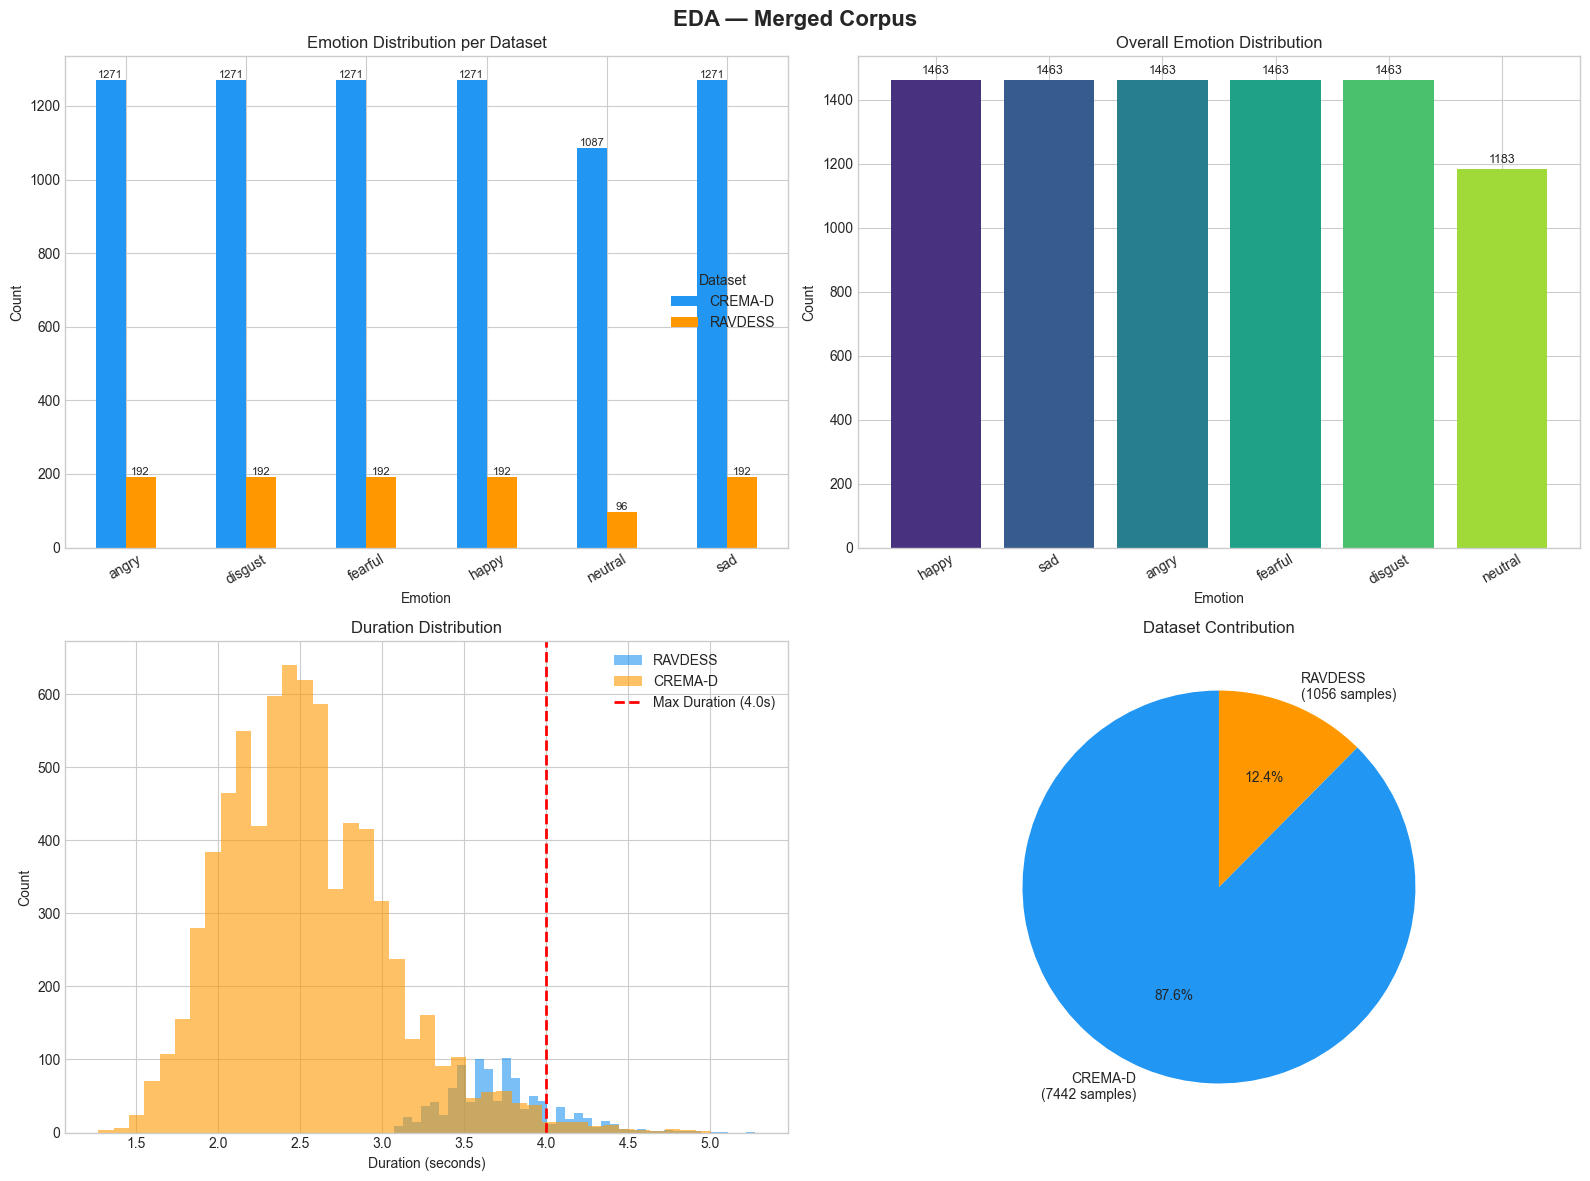

✅ EDA figure saved


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — Merged Corpus", fontsize=16, fontweight="bold")

# ── Plot 1: Emotion distribution per dataset ───────────────────────────────
ax1 = axes[0, 0]
emo_counts = df.groupby(["emotion", "dataset"]).size().unstack(fill_value=0)
emo_counts.plot(kind="bar", ax=ax1, color=["#2196F3", "#FF9800"])
ax1.set_title("Emotion Distribution per Dataset")
ax1.set_xlabel("Emotion")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)
ax1.legend(title="Dataset")
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8)

# ── Plot 2: Overall emotion distribution ──────────────────────────────────
ax2 = axes[0, 1]
emotion_total = df["emotion"].value_counts()
bars = ax2.bar(emotion_total.index, emotion_total.values,
               color=sns.color_palette("viridis", len(emotion_total)))
ax2.set_title("Overall Emotion Distribution")
ax2.set_xlabel("Emotion")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, emotion_total.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha="center", va="bottom", fontsize=9)

# ── Plot 3: Duration distribution ─────────────────────────────────────────
ax3 = axes[1, 0]
for dataset, color in [("RAVDESS", "#2196F3"), ("CREMA-D", "#FF9800")]:
    subset = df[df["dataset"] == dataset]["duration"]
    ax3.hist(subset, bins=40, alpha=0.6, label=dataset, color=color)
ax3.axvline(Config.MAX_DURATION, color="red", linestyle="--",
            linewidth=2, label=f"Max Duration ({Config.MAX_DURATION}s)")
ax3.set_title("Duration Distribution")
ax3.set_xlabel("Duration (seconds)")
ax3.set_ylabel("Count")
ax3.legend()

# ── Plot 4: Dataset contribution pie ──────────────────────────────────────
ax4 = axes[1, 1]
dataset_counts = df["dataset"].value_counts()
ax4.pie(dataset_counts.values,
        labels=[f"{d}\n({c} samples)" for d, c in dataset_counts.items()],
        autopct="%1.1f%%",
        colors=["#2196F3", "#FF9800"],
        startangle=90)
ax4.set_title("Dataset Contribution")

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA figure saved")

In [8]:
# ── Duration statistics ────────────────────────────────────────────────────
print("Duration Statistics (seconds):")
print(df["duration"].describe().round(3).to_string())
print(f"\nSamples that will be PADDED   (dur < {Config.MAX_DURATION}s): "
      f"{(df['duration'] < Config.MAX_DURATION).sum()}")
print(f"Samples that will be CROPPED  (dur > {Config.MAX_DURATION}s): "
      f"{(df['duration'] > Config.MAX_DURATION).sum()}")
print(f"\nSpeakers per dataset:")
print(df.groupby("dataset")["speaker_id"].nunique().to_string())

Duration Statistics (seconds):
count    8498.000
mean        2.689
std         0.624
min         1.268
25%         2.269
50%         2.569
75%         3.036
max         5.272

Samples that will be PADDED   (dur < 4.0s): 8216
Samples that will be CROPPED  (dur > 4.0s): 282

Speakers per dataset:
dataset
CREMA-D    91
RAVDESS    24


---
## Phase 5 — Audio Preprocessing + Feature Extraction

In [9]:
# ── Preprocessing ──────────────────────────────────────────────────────────
def load_and_preprocess(path: str, sr: int, max_samples: int) -> np.ndarray:
    """
    Load → Mono → Resample → Trim → RMS Normalize → Pad/Crop
    Cropping is left-crop (take last max_samples).
    """
    y, _ = librosa.load(path, sr=sr, mono=True)
    y, _ = librosa.effects.trim(y, top_db=Config.TRIM_TOP_DB)

    # Guard degenerate clips
    if len(y) < 100:
        y = np.pad(y, (0, 100), mode="constant")

    # RMS normalization
    rms = np.sqrt(np.mean(y ** 2))
    if rms > 0:
        y = y / rms

    # Pad or crop to fixed length
    if len(y) < max_samples:
        y = np.pad(y, (0, max_samples - len(y)), mode="constant")
    else:
        y = y[-max_samples:]   # left-crop: keep last max_samples

    return y.astype(np.float32)


# ── Feature extractors ─────────────────────────────────────────────────────
def extract_mfcc_features(y: np.ndarray, sr: int) -> Dict[str, np.ndarray]:
    """
    Returns:
      'stats'    : flat vector (4 × N_MFCC = 160) for SVM
      'sequence' : matrix (N_MFCC, T) for CNN1D

    Extended features for SVM (172 total):
      MFCC stats (160) + ZCR (4) + RMS (4) + Spectral Centroid (4)
    """
    mfcc    = librosa.feature.mfcc(y=y, sr=sr,
                                    n_mfcc=Config.N_MFCC,
                                    hop_length=Config.HOP_LENGTH)
    zcr     = librosa.feature.zero_crossing_rate(y, hop_length=Config.HOP_LENGTH)
    rms     = librosa.feature.rms(y=y, hop_length=Config.HOP_LENGTH)
    centroid= librosa.feature.spectral_centroid(y=y, sr=sr,
                                                hop_length=Config.HOP_LENGTH)

    def stats(x):
        return np.concatenate([
            np.mean(x, axis=1), np.std(x, axis=1),
            np.min(x,  axis=1), np.max(x, axis=1)
        ])

    mfcc_stats = stats(mfcc)           # 160
    zcr_stats  = stats(zcr)            #   4
    rms_stats  = stats(rms)            #   4
    cent_stats = stats(centroid)       #   4

    svm_features = np.concatenate(
        [mfcc_stats, zcr_stats, rms_stats, cent_stats]
    ).astype(np.float32)               # 172 total

    return {
        "stats"    : svm_features,
        "sequence" : mfcc.astype(np.float32),   # (N_MFCC, T)
    }


def extract_logmel_raw(y: np.ndarray, sr: int) -> np.ndarray:
    """
    3-channel raw log-mel spectrogram: static + delta + delta-delta.

    IMPORTANT:
    - ref=1.0  (absolute reference — NOT sample-dependent)
    - NO per-sample normalization
    - Normalization happens AFTER the split using train statistics only

    Shape: (3, N_MELS, T)
    """
    mel     = librosa.feature.melspectrogram(
        y=y, sr=sr,
        n_mels=Config.N_MELS,
        hop_length=Config.HOP_LENGTH,
        n_fft=Config.N_FFT
    )
    log_mel = librosa.power_to_db(mel, ref=1.0)   # absolute reference
    delta1  = librosa.feature.delta(log_mel)
    delta2  = librosa.feature.delta(log_mel, order=2)

    return np.stack([log_mel, delta1, delta2], axis=0).astype(np.float32)


print("✅ Preprocessing and feature extraction functions defined")
print(f"  SVM feature vector length : 172")
print(f"  CNN1D input shape         : ({Config.N_MFCC}, T)")
print(f"  CNN2D/PANNs input shape   : (3, {Config.N_MELS}, T)  [raw, unnormalized]")
print(f"  Wav2Vec2 input length     : {Config.MAX_SAMPLES_WAV2VEC2} samples @ 16kHz")

✅ Preprocessing and feature extraction functions defined
  SVM feature vector length : 172
  CNN1D input shape         : (40, T)
  CNN2D/PANNs input shape   : (3, 128, T)  [raw, unnormalized]
  Wav2Vec2 input length     : 64000 samples @ 16kHz


---
## Phase 6 — Save Raw Cache

In [10]:
def build_cache(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """
    Extract all features and save to disk.
    Cache files:
      features_mfcc_{hash}.npz       — SVM stats (172) + CNN1D sequences
      features_logmel_raw_{hash}.npz — raw log-mel (3, N_MELS, T), NOT normalized
      features_waveform_{hash}.npz   — 16kHz waveforms for Wav2Vec2

    normalization_stats are NOT saved here.
    They are computed in Phase 8 after the split.
    """
    h = Config.config_hash()
    cache = {
        "mfcc"    : Config.CACHE_DIR / f"features_mfcc_{h}.npz",
        "logmel"  : Config.CACHE_DIR / f"features_logmel_raw_{h}.npz",
        "waveform": Config.CACHE_DIR / f"features_waveform_{h}.npz",
    }

    # Load from cache if all files exist
    if all(p.exists() for p in cache.values()):
        print("[✓] Valid cache found — loading from disk...")
        d_mfcc  = np.load(cache["mfcc"],     allow_pickle=True)
        d_mel   = np.load(cache["logmel"],   allow_pickle=True)
        d_wave  = np.load(cache["waveform"], allow_pickle=True)
        print(f"    MFCC stats   : {d_mfcc['X_stats'].shape}")
        print(f"    MFCC seq     : {d_mfcc['X_seq'].shape}")
        print(f"    LogMel raw   : {d_mel['X'].shape}")
        print(f"    Waveform     : {d_wave['X'].shape}")
        return {
            "X_stats" : d_mfcc["X_stats"],
            "X_seq"   : d_mfcc["X_seq"],
            "X_mel"   : d_mel["X"],
            "X_wave"  : d_wave["X"],
            "y"       : d_mfcc["y"],
            "paths"   : d_mfcc["paths"],
        }

    # ── Extract features ──────────────────────────────────────────────────
    print("[ ] Extracting features (this may take 10-30 minutes)...")
    X_stats, X_seq, X_mel, X_wave = [], [], [], []
    y_list, paths_list = [], []
    skipped = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Feature extraction"):
        try:
            y_22k = load_and_preprocess(row["filepath"], Config.SR,
                                         Config.MAX_SAMPLES)
            y_16k = load_and_preprocess(row["filepath"], Config.SR_WAV2VEC2,
                                         Config.MAX_SAMPLES_WAV2VEC2)

            mfcc_feats = extract_mfcc_features(y_22k, Config.SR)
            logmel_raw = extract_logmel_raw(y_22k, Config.SR)

            X_stats.append(mfcc_feats["stats"])
            X_seq.append(mfcc_feats["sequence"])
            X_mel.append(logmel_raw)
            X_wave.append(y_16k)
            y_list.append(row["label"])
            paths_list.append(row["filepath"])

        except Exception as exc:
            print(f"  ⚠️  Skipped: {row['filepath']} → {exc}")
            skipped += 1

    if skipped:
        print(f"  ↳ {skipped} file(s) skipped")

    X_stats = np.array(X_stats, dtype=np.float32)
    X_seq   = np.array(X_seq,   dtype=np.float32)
    X_mel   = np.array(X_mel,   dtype=np.float32)
    X_wave  = np.array(X_wave,  dtype=np.float32)
    y_arr   = np.array(y_list,  dtype=np.int64)
    p_arr   = np.array(paths_list)

    np.savez_compressed(cache["mfcc"],     X_stats=X_stats, X_seq=X_seq,
                                            y=y_arr, paths=p_arr)
    np.savez_compressed(cache["logmel"],   X=X_mel,   y=y_arr, paths=p_arr)
    np.savez_compressed(cache["waveform"], X=X_wave,  y=y_arr, paths=p_arr)

    print(f"[✓] Cache saved — hash: {h}")
    print(f"    MFCC stats   : {X_stats.shape}  (SVM input — 172 features)")
    print(f"    MFCC seq     : {X_seq.shape}")
    print(f"    LogMel raw   : {X_mel.shape}  (NOT normalized yet)")
    print(f"    Waveform     : {X_wave.shape}")

    return {
        "X_stats": X_stats, "X_seq": X_seq,
        "X_mel"  : X_mel,   "X_wave": X_wave,
        "y"      : y_arr,   "paths" : p_arr,
    }


# ── Run cache ─────────────────────────────────────────────────────────────
cache_data = build_cache(df)

# Sync df to only include successfully extracted files
df_cached = df[df["filepath"].isin(cache_data["paths"])].reset_index(drop=True)

print(f"\nFinal dataset size after cache: {len(df_cached)} samples")

[✓] Valid cache found — loading from disk...
    MFCC stats   : (8498, 172)


    MFCC seq     : (8498, 40, 173)


    LogMel raw   : (8498, 3, 128, 173)


    Waveform     : (8498, 64000)



Final dataset size after cache: 8498 samples


---
## Phase 7 — Dataset-Stratified Speaker-Independent Split

In [11]:
from dataclasses import dataclass

@dataclass
class SplitData:
    """Named container — eliminates fragile integer indexing."""
    X_stats    : np.ndarray
    X_seq      : np.ndarray
    X_mel_raw  : np.ndarray   # NOT normalized yet
    X_wave     : np.ndarray
    y          : np.ndarray
    speaker_ids: np.ndarray
    datasets   : np.ndarray   # 'RAVDESS' or 'CREMA-D' per sample


def dataset_stratified_speaker_split(
    df: pd.DataFrame,
    features: Dict[str, np.ndarray],
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = 42,
) -> Dict[str, SplitData]:
    """
    DESIGN FREEZE specification:
    1. Split RAVDESS speakers independently
    2. Split CREMA-D speakers independently
    3. Merge train speakers from both datasets
    4. Merge val speakers from both datasets
    5. Merge test speakers from both datasets

    Guarantees:
    - No speaker appears in more than one split
    - Both datasets are proportionally represented in every split
    - random_state=42 for full reproducibility
    """
    train_idx_all, val_idx_all, test_idx_all = [], [], []

    for dataset_name in ["RAVDESS", "CREMA-D"]:
        ds_mask    = (df["dataset"] == dataset_name).values
        ds_indices = np.where(ds_mask)[0]
        speakers   = df.iloc[ds_indices]["speaker_id"].values

        unique_speakers = np.unique(speakers)
        n_speakers      = len(unique_speakers)

        # Step 1: split off test speakers
        gss_test = GroupShuffleSplit(
            n_splits=1, test_size=test_size, random_state=seed
        )
        trainval_spk_idx, test_spk_idx = next(
            gss_test.split(ds_indices, groups=speakers)
        )
        trainval_idx = ds_indices[trainval_spk_idx]
        test_idx     = ds_indices[test_spk_idx]

        # Step 2: split remaining into train/val
        trainval_speakers = df.iloc[trainval_idx]["speaker_id"].values
        adjusted_val_size = val_size / (1.0 - test_size)

        gss_val = GroupShuffleSplit(
            n_splits=1, test_size=adjusted_val_size, random_state=seed
        )
        train_spk_idx, val_spk_idx = next(
            gss_val.split(trainval_idx, groups=trainval_speakers)
        )
        train_idx = trainval_idx[train_spk_idx]
        val_idx   = trainval_idx[val_spk_idx]

        train_idx_all.extend(train_idx)
        val_idx_all.extend(val_idx)
        test_idx_all.extend(test_idx)

        print(f"  {dataset_name:<8}  speakers: {n_speakers}  "
              f"→ train: {len(np.unique(df.iloc[train_idx]['speaker_id']))}  "
              f"val: {len(np.unique(df.iloc[val_idx]['speaker_id']))}  "
              f"test: {len(np.unique(df.iloc[test_idx]['speaker_id']))}")

    train_idx = np.array(train_idx_all)
    val_idx   = np.array(val_idx_all)
    test_idx  = np.array(test_idx_all)

    # ── Verify zero speaker overlap ────────────────────────────────────────
    train_spk = set(df.iloc[train_idx]["speaker_id"])
    val_spk   = set(df.iloc[val_idx]["speaker_id"])
    test_spk  = set(df.iloc[test_idx]["speaker_id"])

    assert len(train_spk & val_spk)  == 0, "LEAK: Train ∩ Val speakers!"
    assert len(train_spk & test_spk) == 0, "LEAK: Train ∩ Test speakers!"
    assert len(val_spk   & test_spk) == 0, "LEAK: Val ∩ Test speakers!"
    print("  ✅ Zero speaker overlap verified")

    # ── Verify all classes present in every split ──────────────────────────
    for split_name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
        classes_present = np.unique(features["y"][idx])
        assert len(classes_present) == len(Config.EMOTIONS), \
            f"Split '{split_name}' missing class(es): {set(range(len(Config.EMOTIONS))) - set(classes_present)}"
    print("  ✅ All 6 classes present in every split")

    def make_split(idx):
        return SplitData(
            X_stats    = features["X_stats"][idx],
            X_seq      = features["X_seq"][idx],
            X_mel_raw  = features["X_mel"][idx],
            X_wave     = features["X_wave"][idx],
            y          = features["y"][idx],
            speaker_ids= df.iloc[idx]["speaker_id"].values,
            datasets   = df.iloc[idx]["dataset"].values,
        )

    return {
        "train": make_split(train_idx),
        "val"  : make_split(val_idx),
        "test" : make_split(test_idx),
    }


print("Performing dataset-stratified speaker-independent split...")
splits = dataset_stratified_speaker_split(df_cached, cache_data)

print("\nSplit Summary:")
print(f"{'Split':<6} {'Samples':>8} {'Speakers':>9} {'RAVDESS':>9} {'CREMA-D':>9}")
print("-" * 45)
for name, sp in splits.items():
    n_rav = (sp.datasets == "RAVDESS").sum()
    n_cre = (sp.datasets == "CREMA-D").sum()
    print(f"{name:<6} {len(sp.y):>8} {len(np.unique(sp.speaker_ids)):>9} "
          f"{n_rav:>9} {n_cre:>9}")

Performing dataset-stratified speaker-independent split...
  RAVDESS   speakers: 24  → train: 16  val: 4  test: 4
  CREMA-D   speakers: 91  → train: 63  val: 14  test: 14
  ✅ Zero speaker overlap verified
  ✅ All 6 classes present in every split



Split Summary:
Split   Samples  Speakers   RAVDESS   CREMA-D
---------------------------------------------
train      5851        79       704      5147
val        1323        18       176      1147
test       1324        18       176      1148


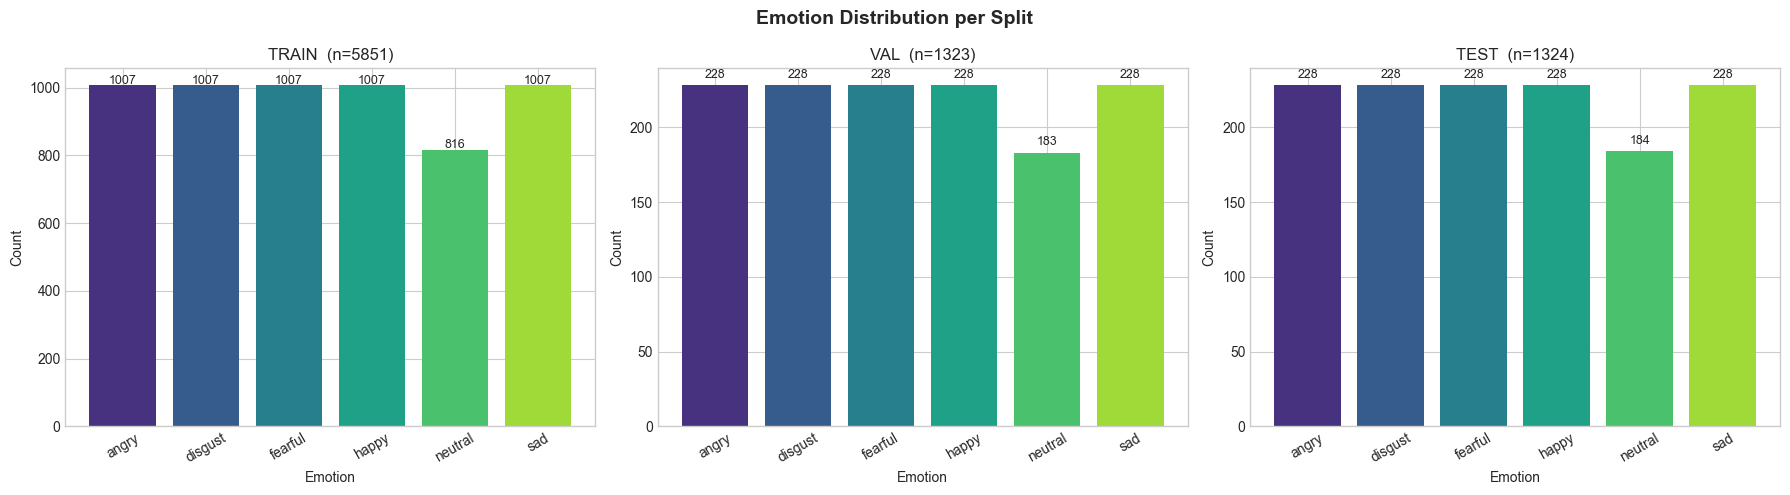

✅ Split distribution figure saved


In [12]:
# ── Visualize split distributions ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Emotion Distribution per Split", fontsize=14, fontweight="bold")

for ax, (name, sp) in zip(axes, splits.items()):
    counts = pd.Series(sp.y).value_counts().sort_index()
    ax.bar(
        [Config.EMOTIONS[i] for i in counts.index],
        counts.values,
        color=sns.color_palette("viridis", len(Config.EMOTIONS))
    )
    ax.set_title(f"{name.upper()}  (n={len(sp.y)})")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "split_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Split distribution figure saved")

---
## Phase 8 — Compute Train Statistics (LogMel only)

In [13]:
def compute_train_statistics(train_split: SplitData) -> Dict[str, float]:
    """
    Compute global mean and std from TRAINING SET ONLY.

    These statistics are then applied to train / val / test uniformly.
    This prevents data leakage from val/test into normalization.

    Returns dict with 'mean' and 'std' scalars.
    """
    train_mel = train_split.X_mel_raw   # shape: (N_train, 3, N_MELS, T)
    mean = float(train_mel.mean())
    std  = float(train_mel.std())
    print(f"  LogMel global mean (train) : {mean:.4f}")
    print(f"  LogMel global std  (train) : {std:.4f}")
    return {"mean": mean, "std": std}


print("Computing normalization statistics from TRAIN set only...")
norm_stats = compute_train_statistics(splits["train"])

# Save normalization stats
h = Config.config_hash()
norm_path = Config.CACHE_DIR / f"normalization_stats_{h}.npz"
np.savez(norm_path, mean=norm_stats["mean"], std=norm_stats["std"])
print(f"  ✅ Normalization stats saved → {norm_path.name}")

Computing normalization statistics from TRAIN set only...


  LogMel global mean (train) : -6.7299
  LogMel global std  (train) : 14.3850
  ✅ Normalization stats saved → normalization_stats_f36fbb73.npz


---
## Phase 9 — Apply Global Normalization

In [14]:
def apply_normalization(
    splits: Dict[str, SplitData],
    norm_stats: Dict[str, float]
) -> Dict[str, SplitData]:
    """
    Apply global normalization to LogMel features in all splits.
    Uses TRAIN statistics only — same values for train/val/test.

    This replaces X_mel_raw with X_mel_norm in each SplitData.
    """
    mean = norm_stats["mean"]
    std  = norm_stats["std"]

    normalized = {}
    for name, sp in splits.items():
        X_norm = (sp.X_mel_raw - mean) / (std + 1e-9)
        # Replace raw with normalized — keep everything else identical
        normalized[name] = SplitData(
            X_stats    = sp.X_stats,
            X_seq      = sp.X_seq,
            X_mel_raw  = X_norm,   # now normalized
            X_wave     = sp.X_wave,
            y          = sp.y,
            speaker_ids= sp.speaker_ids,
            datasets   = sp.datasets,
        )
        print(f"  {name:<5}  X_mel mean: {X_norm.mean():.4f}  std: {X_norm.std():.4f}")

    return normalized


print("Applying global normalization to LogMel features...")
splits = apply_normalization(splits, norm_stats)
print("  ✅ LogMel normalization applied to train / val / test")
print("  ✅ MFCC and waveform features unchanged (no normalization needed here)")

Applying global normalization to LogMel features...


  train  X_mel mean: 0.0000  std: 1.0000


  val    X_mel mean: 0.0006  std: 1.0006


  test   X_mel mean: -0.0174  std: 1.0167
  ✅ LogMel normalization applied to train / val / test
  ✅ MFCC and waveform features unchanged (no normalization needed here)


---
## Phase 10 — Compute Class Weights + Create Datasets & DataLoaders

In [15]:
# ── Class weights from TRAIN only ─────────────────────────────────────────
raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(Config.EMOTIONS)),
    y=splits["train"].y
)
class_weights = {i: float(w) for i, w in enumerate(raw_weights)}
weight_tensor = torch.tensor(
    list(class_weights.values()), dtype=torch.float32
).to(Config.DEVICE)

print("Class weights (from train set):")
for emotion, idx in Config.EMOTION_TO_IDX.items():
    print(f"  {emotion:<10} (label {idx}): {class_weights[idx]:.4f}")

Class weights (from train set):
  angry      (label 0): 0.9684
  disgust    (label 1): 0.9684
  fearful    (label 2): 0.9684
  happy      (label 3): 0.9684
  neutral    (label 4): 1.1951
  sad        (label 5): 0.9684


In [16]:
# ── Dataset classes ────────────────────────────────────────────────────────
class BaseDataset(Dataset):
    """Generic dataset for pre-computed feature arrays."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class Wav2Vec2Dataset(Dataset):
    """
    Stores raw waveform arrays only.
    Does NOT call the processor in __getitem__.
    Processing is done in the custom collate_fn below.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = X   # raw numpy arrays, not tensors
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Return raw waveform as numpy — collate_fn handles batching
        return self.X[idx], self.y[idx]


# ── Global singleton for Wav2Vec2 processor ────────────────────────────────
_W2V_EXTRACTOR = None

def _get_w2v_extractor():
    global _W2V_EXTRACTOR
    if _W2V_EXTRACTOR is None:
        print("  [W2V] Loading Wav2Vec2FeatureExtractor (once)...")
        _W2V_EXTRACTOR = Wav2Vec2FeatureExtractor.from_pretrained(
            "facebook/wav2vec2-base"
        )
    return _W2V_EXTRACTOR


def wav2vec2_collate_fn(batch):
    """
    Custom collate for Wav2Vec2Dataset.
    Applies Wav2Vec2FeatureExtractor on the BATCH (not per-sample)
    to correctly compute attention masks for padded sequences.
    Uses cached singleton processor for efficiency.
    """
    waveforms = [item[0] for item in batch]
    labels    = torch.stack([item[1] for item in batch])

    extractor = _get_w2v_extractor()  # cached singleton — fast
    inputs = extractor(
        waveforms,
        sampling_rate=Config.SR_WAV2VEC2,
        return_tensors="pt",
        padding=True,
    )
    
    attention_mask = inputs.get("attention_mask")
    if attention_mask is None:
        attention_mask = torch.ones(inputs["input_values"].shape, dtype=torch.long)
        
    return (
        inputs["input_values"],
        labels,
        attention_mask,
    )


# ── Build DataLoaders ──────────────────────────────────────────────────────
def create_dataloaders(splits: Dict[str, SplitData],
                       batch_size: int = 32) -> Dict:
    loaders = {}

    for mode in ["mfcc_stats", "mfcc_seq", "logmel", "waveform"]:
        loaders[mode] = {}

    for split_name, sp in splits.items():
        shuffle = (split_name == "train")

        loaders["mfcc_stats"][split_name] = DataLoader(
            BaseDataset(sp.X_stats, sp.y),
            batch_size=batch_size, shuffle=shuffle,
            num_workers=0, pin_memory=True
        )
        loaders["mfcc_seq"][split_name] = DataLoader(
            BaseDataset(sp.X_seq, sp.y),
            batch_size=batch_size, shuffle=shuffle,
            num_workers=0, pin_memory=True
        )
        loaders["logmel"][split_name] = DataLoader(
            BaseDataset(sp.X_mel_raw, sp.y),
            batch_size=batch_size, shuffle=shuffle,
            num_workers=0, pin_memory=True
        )
        if TRANSFORMERS_AVAILABLE:
            loaders["waveform"][split_name] = DataLoader(
                Wav2Vec2Dataset(sp.X_wave, sp.y),
                batch_size=batch_size // 2, shuffle=shuffle,
                collate_fn=wav2vec2_collate_fn,
                num_workers=0
            )

    return loaders


loaders = create_dataloaders(splits, Config.BATCH_SIZE)

# ── Sanity check shapes ────────────────────────────────────────────────────
print("DataLoader shape verification:")
x, y = next(iter(loaders["mfcc_stats"]["train"]))
print(f"  mfcc_stats : x={tuple(x.shape)}  y={tuple(y.shape)}")

x, y = next(iter(loaders["mfcc_seq"]["train"]))
print(f"  mfcc_seq   : x={tuple(x.shape)}  y={tuple(y.shape)}")

x, y = next(iter(loaders["logmel"]["train"]))
print(f"  logmel     : x={tuple(x.shape)}  y={tuple(y.shape)}")

if TRANSFORMERS_AVAILABLE and "train" in loaders.get("waveform", {}):
    x, y, mask = next(iter(loaders["waveform"]["train"]))
    print(f"  waveform   : x={tuple(x.shape)}  y={tuple(y.shape)}  mask={tuple(mask.shape)}")

print("✅ All DataLoaders ready")


DataLoader shape verification:
  mfcc_stats : x=(32, 172)  y=(32,)
  mfcc_seq   : x=(32, 40, 173)  y=(32,)
  logmel     : x=(32, 3, 128, 173)  y=(32,)
  [W2V] Loading Wav2Vec2FeatureExtractor (once)...


  waveform   : x=(16, 64000)  y=(16,)  mask=(16, 64000)
✅ All DataLoaders ready


---
## Evaluation Helper — Used by All Models

In [17]:
def evaluate_model(
    model_name : str,
    model,
    test_split : SplitData,
    test_loader,
    is_pytorch : bool = True,
    is_w2v2    : bool = False,
) -> Dict:
    """
    Full evaluation with per-dataset breakdown.

    Reports:
      - Overall: Accuracy, UAR, Macro F1, Weighted F1
      - RAVDESS-only subset
      - CREMA-D-only subset
      - Confusion matrix
      - Classification report
    """
    preds_all = []
    labels_all = []

    if is_pytorch:
        model.eval()
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"  Evaluating {model_name}"):
                if is_w2v2:
                    x, y, mask = [b.to(Config.DEVICE) for b in batch]
                    logits = model(x, attention_mask=mask)
                else:
                    x, y = [b.to(Config.DEVICE) for b in batch]
                    logits = model(x)
                preds_all.extend(torch.argmax(logits, dim=1).cpu().numpy())
                labels_all.extend(y.cpu().numpy())
    else:
        # sklearn
        X_te = test_split.X_stats
        preds_all  = model.predict(X_te).tolist()
        labels_all = test_split.y.tolist()

    preds_all  = np.array(preds_all)
    labels_all = np.array(labels_all)

    def metrics(y_true, y_pred, prefix=""):
        return {
            f"{prefix}accuracy"   : float(accuracy_score(y_true, y_pred)),
            f"{prefix}uar"        : float(recall_score(y_true, y_pred,
                                        average="macro", zero_division=0)),
            f"{prefix}macro_f1"  : float(f1_score(y_true, y_pred,
                                        average="macro", zero_division=0)),
            f"{prefix}weighted_f1": float(f1_score(y_true, y_pred,
                                        average="weighted", zero_division=0)),
        }

    results = {"model": model_name}
    results.update(metrics(labels_all, preds_all))  # overall

    # ── Per-dataset breakdown ──────────────────────────────────────────────
    for ds_name in ["RAVDESS", "CREMA-D"]:
        ds_mask = (test_split.datasets == ds_name)
        if ds_mask.sum() > 0:
            prefix = f"{ds_name.lower().replace('-','_')}_"
            results.update(metrics(
                labels_all[ds_mask], preds_all[ds_mask], prefix=prefix
            ))
            results[f"{prefix}n_samples"] = int(ds_mask.sum())

    # ── Confusion matrix ───────────────────────────────────────────────────
    cm = confusion_matrix(labels_all, preds_all)
    results["confusion_matrix"] = cm.tolist()

    # ── Plot confusion matrix ──────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=Config.EMOTIONS, yticklabels=Config.EMOTIONS, ax=ax
    )
    ax.set_title(f"{model_name} — Confusion Matrix (normalized)")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    fig.savefig(
        Config.FIGURES_DIR / f"cm_{model_name.lower().replace(' ','_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

    # ── Classification report ──────────────────────────────────────────────
    print(f"\n  Classification Report — {model_name}")
    print(classification_report(
        labels_all, preds_all,
        target_names=Config.EMOTIONS, zero_division=0
    ))

    # ── Print summary ──────────────────────────────────────────────────────
    print(f"  {'Metric':<20} {'Overall':>10} {'RAVDESS':>10} {'CREMA-D':>10}")
    print("  " + "-" * 52)
    for m in ["accuracy", "uar", "macro_f1", "weighted_f1"]:
        ov  = results.get(m, float("nan"))
        rav = results.get(f"ravdess_{m}", float("nan"))
        cre = results.get(f"crema_d_{m}", float("nan"))
        print(f"  {m:<20} {ov:>10.4f} {rav:>10.4f} {cre:>10.4f}")

    # ── Save JSON ──────────────────────────────────────────────────────────
    out_path = Config.RESULTS_DIR / f"{model_name.lower().replace(' ','_')}_results.json"
    with open(out_path, "w") as f:
        json.dump(results, f, indent=2)

    return results


print("✅ Evaluation function ready")

✅ Evaluation function ready


---
## Training Loop Helper — Used by All Deep Learning Models

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    weight_tensor,
    epochs    : int   = 50,
    lr        : float = 1e-3,
    patience  : int   = 10,
    name      : str   = "Model",
    is_w2v2   : bool  = False,
    use_mixup : bool  = False,
) -> Tuple:
    """
    Standard training loop with:
    - Weighted CrossEntropy + label smoothing
    - AdamW optimizer
    - ReduceLROnPlateau scheduler
    - LR logged every epoch
    - Early stopping on val Macro F1
    - Best checkpoint saved with config_hash in filename
    - Mixup: Beta(0.4,0.4) + max(lam, 1-lam) + prob=0.3
    """
    model = model.to(Config.DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=weight_tensor, label_smoothing=0.1
    )

    effective_lr = 1e-5 if is_w2v2 else lr
    optimizer    = optim.AdamW(
        model.parameters(), lr=effective_lr,
        weight_decay=Config.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=4, 
    )

    h         = Config.config_hash()
    ckpt_path = Config.CHECKPOINT_DIR / f"{name}_{h}_best.pth"
    history   = defaultdict(list)
    best_f1   = 0.0
    patience_ctr = 0

    print(f"\n[ ] Training {name}  "
          f"(Mixup: {'ON' if use_mixup else 'OFF'} | "
          f"lr={effective_lr} | device={Config.DEVICE})")

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            if is_w2v2:
                x, y, mask = [b.to(Config.DEVICE) for b in batch]
            else:
                x, y = [b.to(Config.DEVICE) for b in batch]
                mask = None

            optimizer.zero_grad()

            # Mixup augmentation
            if use_mixup and not is_w2v2 and random.random() < 0.3:
                lam = np.random.beta(0.4, 0.4)
                lam = max(lam, 1.0 - lam)   # dominant sample always first
                idx = torch.randperm(x.size(0), device=x.device)
                x_mixed = lam * x + (1.0 - lam) * x[idx]
                y_a, y_b = y, y[idx]
                logits = model(x_mixed)
                loss   = (lam * criterion(logits, y_a)
                          + (1.0 - lam) * criterion(logits, y_b))
            else:
                logits = model(x, attention_mask=mask) if is_w2v2 else model(x)
                loss   = criterion(logits, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                if is_w2v2:
                    x, y, mask = [b.to(Config.DEVICE) for b in batch]
                    logits = model(x, attention_mask=mask)
                else:
                    x, y = [b.to(Config.DEVICE) for b in batch]
                    logits = model(x)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_labels.extend(y.cpu().numpy())

        avg_loss = running_loss / len(train_loader)
        val_f1   = f1_score(val_labels, val_preds,
                             average="macro", zero_division=0)
        val_acc  = accuracy_score(val_labels, val_preds)

        # Get current LR
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(avg_loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        scheduler.step(val_f1)

        # ── Checkpoint & early stopping ────────────────────────────────────
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_ctr = 0
            torch.save(
                {"model_state_dict": model.state_dict(), "best_f1": best_f1},
                ckpt_path
            )
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  ⛔ Early stopping at epoch {epoch}")
                break

        print(f"  Ep {epoch:3d}/{epochs}  "
              f"Loss {avg_loss:.4f}  "
              f"Val-F1 {val_f1:.4f}  "
              f"Val-Acc {val_acc:.4f}  "
              f"LR {current_lr:.2e}")

    # Load best checkpoint
    ckpt = torch.load(ckpt_path, map_location=Config.DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"  [✓] Best checkpoint loaded  (Val F1 = {ckpt['best_f1']:.4f})")

    return model, dict(history)


def plot_training_curves(history: Dict, name: str):
    """Plot and save training loss, val F1, val accuracy, and LR."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{name} — Training Curves", fontsize=14, fontweight="bold")

    axes[0].plot(history["train_loss"], label="Train Loss", color="#F44336")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["val_f1"],  label="Val Macro F1",  color="#2196F3")
    axes[1].plot(history["val_acc"], label="Val Accuracy",  color="#4CAF50")
    axes[1].set_title("Validation Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    axes[2].plot(history["lr"], label="Learning Rate", color="#FF9800")
    axes[2].set_title("Learning Rate Schedule")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].set_yscale("log")
    axes[2].legend()

    plt.tight_layout()
    fig.savefig(
        Config.FIGURES_DIR / f"training_{name.lower().replace(' ','_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()


print("✅ Training loop and plotting functions ready")


✅ Training loop and plotting functions ready


---
## Phase 11 — SVM

In [19]:
print("="*60)
print("  PHASE 11 — SVM")
print("="*60)

# Scale features
scaler   = StandardScaler()
X_tr_svm = scaler.fit_transform(splits["train"].X_stats)
X_va_svm = scaler.transform(splits["val"].X_stats)
X_te_svm = scaler.transform(splits["test"].X_stats)

print(f"  Feature dim : {X_tr_svm.shape[1]}")
print(f"  Train       : {X_tr_svm.shape[0]}")
print(f"  Val         : {X_va_svm.shape[0]}")
print(f"  Test        : {X_te_svm.shape[0]}")

# GroupKFold CV on train set only
train_speakers = splits["train"].speaker_ids
cv_splits = list(
    GroupKFold(n_splits=3).split(
        X_tr_svm, splits["train"].y, groups=train_speakers
    )
)

svm = GridSearchCV(
    SVC(class_weight="balanced", probability=True,
        random_state=Config.SEED),
    param_grid={
        "C"      : [0.1, 1, 10, 100],
        "gamma"  : ["scale", "auto"],
        "kernel" : ["rbf"]
    },
    cv=cv_splits,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)
svm.fit(X_tr_svm, splits["train"].y)

print(f"\n  Best SVM params : {svm.best_params_}")
print(f"  Best CV F1      : {svm.best_score_:.4f}")

  PHASE 11 — SVM
  Feature dim : 172
  Train       : 5851
  Val         : 1323
  Test        : 1324
Fitting 3 folds for each of 8 candidates, totalling 24 fits



  Best SVM params : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1      : 0.5019


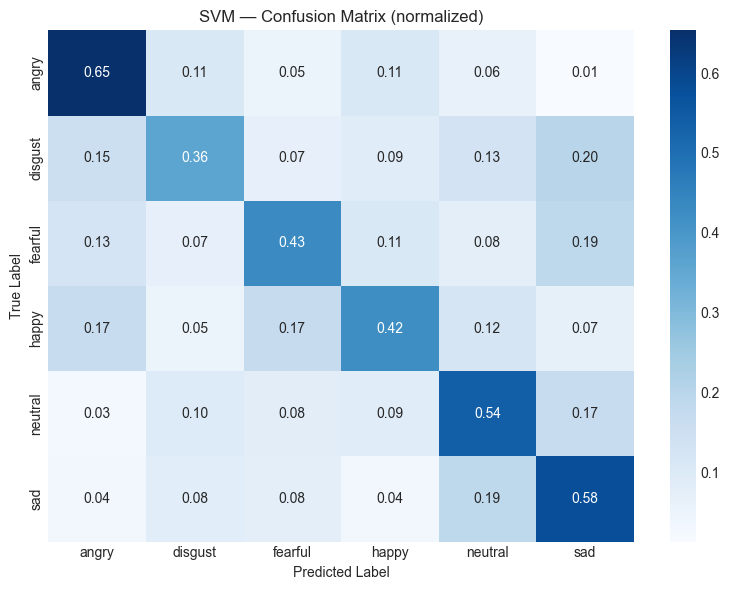


  Classification Report — SVM
              precision    recall  f1-score   support

       angry       0.56      0.65      0.61       228
     disgust       0.48      0.36      0.41       228
     fearful       0.50      0.43      0.46       228
       happy       0.51      0.42      0.46       228
     neutral       0.43      0.54      0.48       184
         sad       0.49      0.58      0.53       228

    accuracy                           0.50      1324
   macro avg       0.49      0.50      0.49      1324
weighted avg       0.50      0.50      0.49      1324

  Metric                  Overall    RAVDESS    CREMA-D
  ----------------------------------------------------
  accuracy                 0.4955     0.4773     0.4983
  uar                      0.4968     0.4740     0.4994
  macro_f1                 0.4905     0.4570     0.4932
  weighted_f1              0.4910     0.4587     0.4936


In [20]:
# Evaluate SVM — inject scaled test features into split
from copy import copy
test_svm_split = copy(splits["test"])
test_svm_split.X_stats = X_te_svm

results_svm = evaluate_model(
    model_name  = "SVM",
    model       = svm,
    test_split  = test_svm_split,
    test_loader = None,
    is_pytorch  = False,
)

---
## Phase 12 — CNN1D + Attention + BiLSTM

  PHASE 12 — CNN1D + Attention + BiLSTM

[ ] Training CNN1D  (Mixup: ON | lr=0.001 | device=cuda)


  Ep   1/50  Loss 1.6299  Val-F1 0.4124  Val-Acc 0.4324  LR 1.00e-03


  Ep   2/50  Loss 1.5253  Val-F1 0.3977  Val-Acc 0.4210  LR 1.00e-03


  Ep   3/50  Loss 1.4713  Val-F1 0.4551  Val-Acc 0.4800  LR 1.00e-03


  Ep   4/50  Loss 1.4379  Val-F1 0.4601  Val-Acc 0.4686  LR 1.00e-03


...

  Ep  33/50  Loss 1.0247  Val-F1 0.5889  Val-Acc 0.5881  LR 5.00e-04


  Ep  34/50  Loss 1.0486  Val-F1 0.5790  Val-Acc 0.5767  LR 5.00e-04


  Ep  35/50  Loss 0.9862  Val-F1 0.5858  Val-Acc 0.5835  LR 5.00e-04


  Ep  36/50  Loss 0.9695  Val-F1 0.5800  Val-Acc 0.5737  LR 5.00e-04


  ⛔ Early stopping at epoch 37
  [✓] Best checkpoint loaded  (Val F1 = 0.5892)


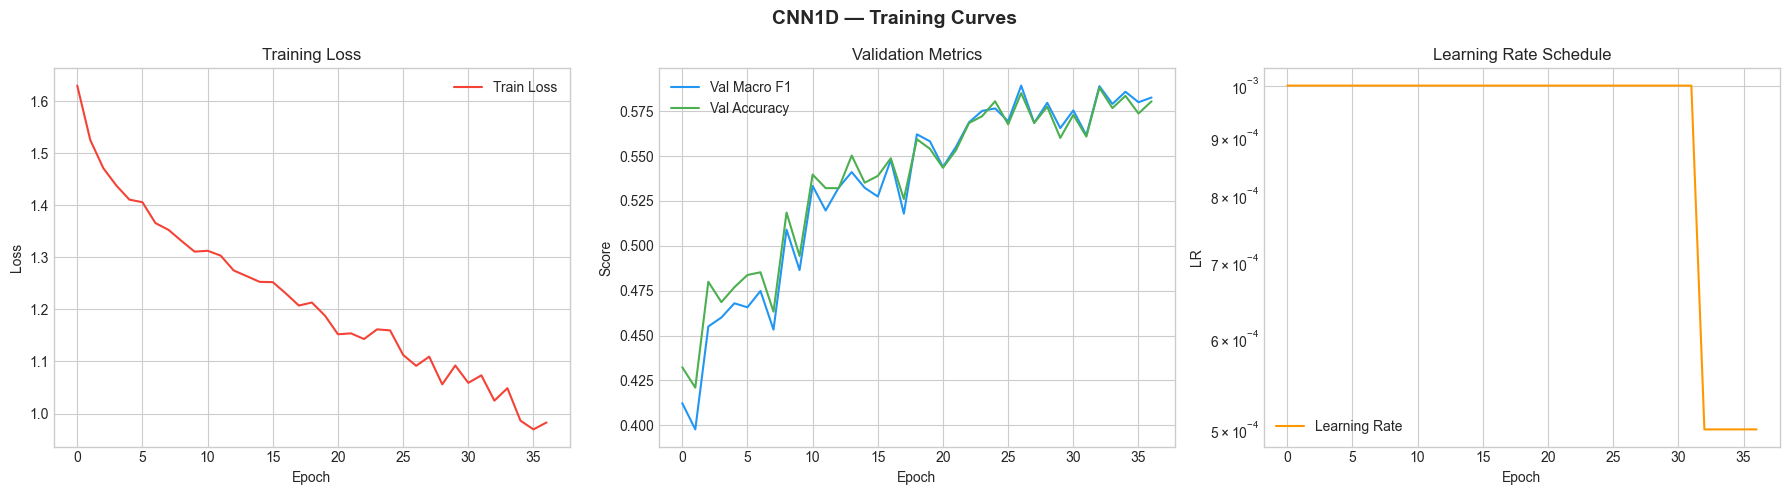

In [21]:
class CNN1D_Attention_BiLSTM(nn.Module):
    """
    Input : (B, N_MFCC, T)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes=6, in_channels=40):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(64,  128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.4),
        )
        self.bilstm    = nn.LSTM(256, 128, num_layers=2, batch_first=True,
                                  bidirectional=True, dropout=0.3)
        self.attention = nn.MultiheadAttention(256, num_heads=4,
                                               dropout=0.3, batch_first=True)
        self.layer_norm = nn.LayerNorm(256)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)           # (B, T', 256)
        lstm_out, _ = self.bilstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        x = torch.mean(self.layer_norm(attn_out + lstm_out), dim=1)
        return self.classifier(x)


print("="*60)
print("  PHASE 12 — CNN1D + Attention + BiLSTM")
print("="*60)

model_1d, history_1d = train_model(
    CNN1D_Attention_BiLSTM(num_classes=len(Config.EMOTIONS),
                            in_channels=Config.N_MFCC),
    loaders["mfcc_seq"]["train"],
    loaders["mfcc_seq"]["val"],
    weight_tensor,
    name      = "CNN1D",
    use_mixup = True,
)
plot_training_curves(history_1d, "CNN1D")

  Evaluating CNN1D:   0%|          | 0/42 [00:00<?, ?it/s]

  Evaluating CNN1D:  62%|██████▏   | 26/42 [00:00<00:00, 251.37it/s]

  Evaluating CNN1D: 100%|██████████| 42/42 [00:00<00:00, 243.02it/s]

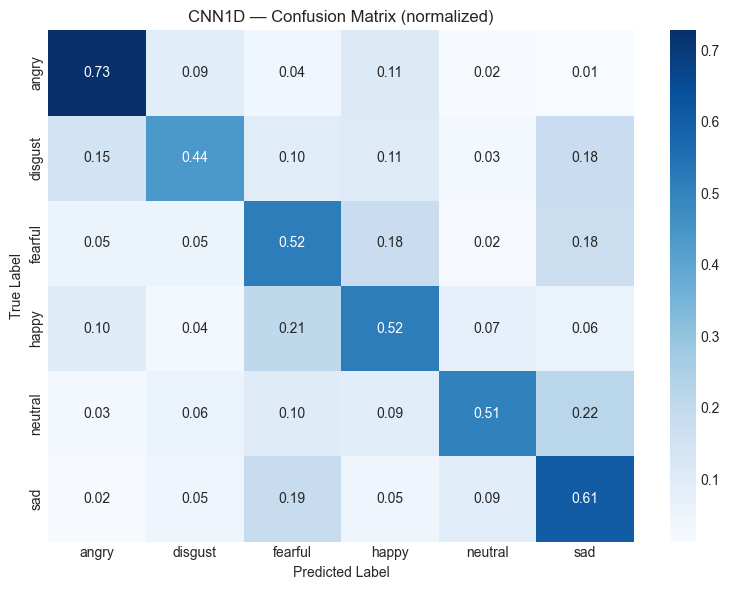


  Classification Report — CNN1D
              precision    recall  f1-score   support

       angry       0.68      0.73      0.70       228
     disgust       0.61      0.44      0.51       228
     fearful       0.46      0.52      0.49       228
       happy       0.50      0.52      0.51       228
     neutral       0.63      0.51      0.56       184
         sad       0.50      0.61      0.55       228

    accuracy                           0.55      1324
   macro avg       0.56      0.55      0.55      1324
weighted avg       0.56      0.55      0.55      1324

  Metric                  Overall    RAVDESS    CREMA-D
  ----------------------------------------------------
  accuracy                 0.5536     0.5739     0.5505
  uar                      0.5521     0.5625     0.5496
  macro_f1                 0.5531     0.5807     0.5477
  weighted_f1              0.5528     0.5826     0.5474


In [22]:
results_cnn1d = evaluate_model(
    "CNN1D", model_1d,
    splits["test"], loaders["mfcc_seq"]["test"]
)

---
## Phase 13 — CNN2D + Attention + BiLSTM

  PHASE 13 — CNN2D + Attention + BiLSTM

[ ] Training CNN2D  (Mixup: ON | lr=0.001 | device=cuda)


  Ep   1/50  Loss 1.7706  Val-F1 0.2787  Val-Acc 0.3364  LR 1.00e-03


  Ep   2/50  Loss 1.6699  Val-F1 0.3157  Val-Acc 0.3764  LR 1.00e-03


  Ep   3/50  Loss 1.6445  Val-F1 0.3635  Val-Acc 0.3961  LR 1.00e-03


  Ep   4/50  Loss 1.6292  Val-F1 0.3404  Val-Acc 0.3787  LR 1.00e-03


...

  Ep  46/50  Loss 1.2338  Val-F1 0.5464  Val-Acc 0.5480  LR 5.00e-04


  Ep  47/50  Loss 1.2108  Val-F1 0.5555  Val-Acc 0.5578  LR 5.00e-04


  Ep  48/50  Loss 1.1814  Val-F1 0.5670  Val-Acc 0.5661  LR 2.50e-04


  Ep  49/50  Loss 1.1841  Val-F1 0.5539  Val-Acc 0.5548  LR 2.50e-04


  Ep  50/50  Loss 1.1917  Val-F1 0.5556  Val-Acc 0.5586  LR 2.50e-04
  [✓] Best checkpoint loaded  (Val F1 = 0.5670)


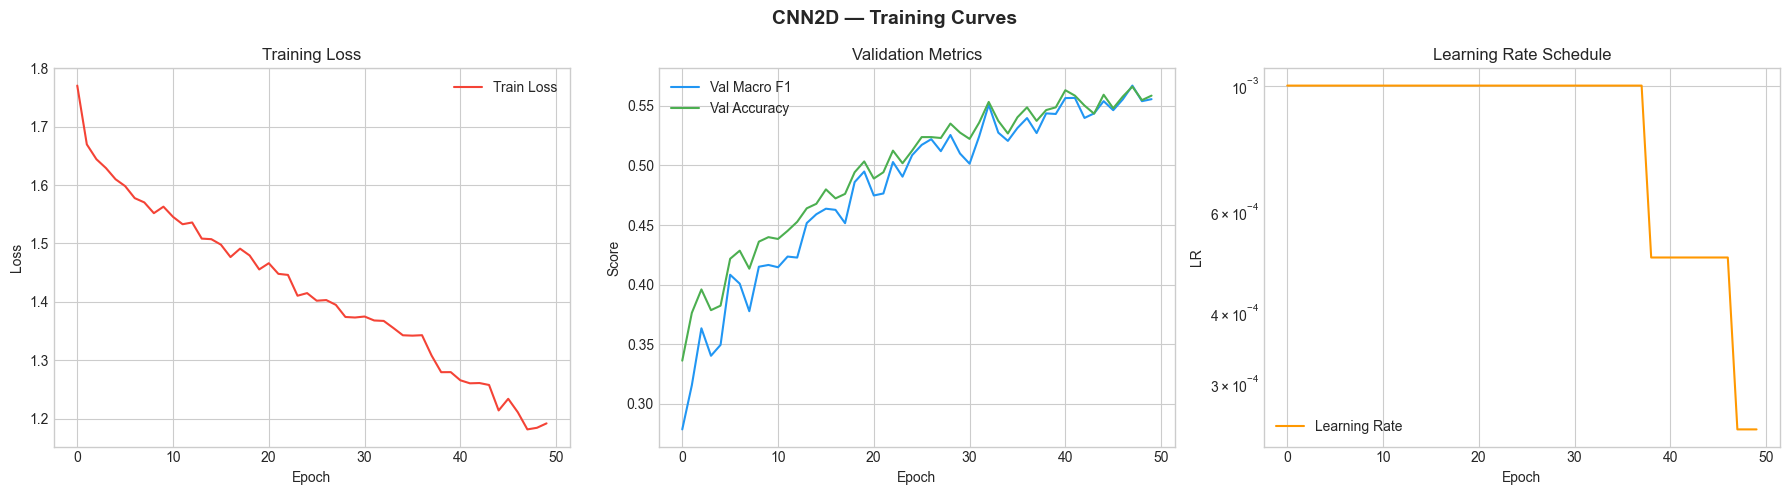

In [23]:
class SpecAugment(nn.Module):
    """Frequency and time masking. Active only during training."""
    def __init__(self, f_mask=15, t_mask=15, p=0.3):
        super().__init__()
        self.f_mask = f_mask
        self.t_mask = t_mask
        self.p      = p

    def forward(self, x):
        if not self.training or torch.rand(1).item() > self.p:
            return x
        x = x.clone()
        B, C, F, T = x.shape
        fw = min(torch.randint(0, self.f_mask + 1, (1,)).item(), F)
        if fw > 0:
            f0 = torch.randint(0, F - fw + 1, (1,)).item()
            x[:, :, f0:f0+fw, :] = 0
        tw = min(torch.randint(0, self.t_mask + 1, (1,)).item(), T)
        if tw > 0:
            t0 = torch.randint(0, T - tw + 1, (1,)).item()
            x[:, :, :, t0:t0+tw] = 0
        return x


class CNN2D_Attention_BiLSTM(nn.Module):
    """
    Input : (B, 3, N_MELS, T)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes=6, in_channels=3):
        super().__init__()
        self.spec_augment = SpecAugment()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.3),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.Dropout2d(0.4),
        )
        self.bilstm    = nn.LSTM(256, 128, num_layers=2, batch_first=True,
                                  bidirectional=True, dropout=0.3)
        self.attention = nn.MultiheadAttention(256, num_heads=4,
                                               dropout=0.3, batch_first=True)
        self.layer_norm = nn.LayerNorm(256)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.spec_augment(x)
        x = self.cnn(x)                                       # (B, 256, F', T')
        x = F.adaptive_avg_pool2d(x, (1, None)).squeeze(2)    # (B, 256, T')
        x = x.permute(0, 2, 1)                                # (B, T', 256)
        lstm_out, _ = self.bilstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        x = torch.mean(self.layer_norm(attn_out + lstm_out), dim=1)
        return self.classifier(x)


print("="*60)
print("  PHASE 13 — CNN2D + Attention + BiLSTM")
print("="*60)

model_2d, history_2d = train_model(
    CNN2D_Attention_BiLSTM(num_classes=len(Config.EMOTIONS)),
    loaders["logmel"]["train"],
    loaders["logmel"]["val"],
    weight_tensor,
    name      = "CNN2D",
    use_mixup = True,
)
plot_training_curves(history_2d, "CNN2D")

  Evaluating CNN2D:   0%|          | 0/42 [00:00<?, ?it/s]

  Evaluating CNN2D:  12%|█▏        | 5/42 [00:00<00:00, 41.99it/s]

  Evaluating CNN2D:  24%|██▍       | 10/42 [00:00<00:00, 41.64it/s]

  Evaluating CNN2D:  36%|███▌      | 15/42 [00:00<00:00, 41.97it/s]

  Evaluating CNN2D:  48%|████▊     | 20/42 [00:00<00:00, 42.26it/s]

  Evaluating CNN2D:  60%|█████▉    | 25/42 [00:00<00:00, 41.25it/s]

  Evaluating CNN2D:  71%|███████▏  | 30/42 [00:00<00:00, 40.53it/s]

  Evaluating CNN2D:  83%|████████▎ | 35/42 [00:00<00:00, 40.51it/s]

  Evaluating CNN2D:  95%|█████████▌| 40/42 [00:00<00:00, 41.04it/s]

  Evaluating CNN2D: 100%|██████████| 42/42 [00:01<00:00, 39.62it/s]

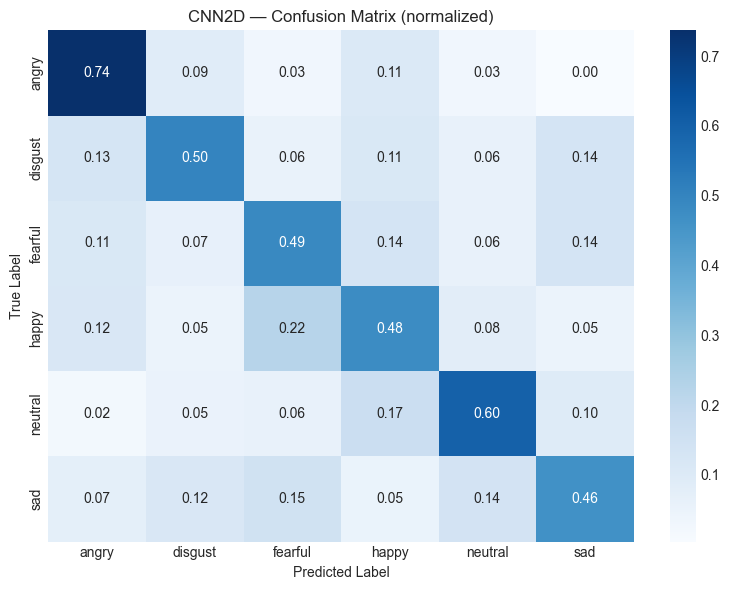


  Classification Report — CNN2D
              precision    recall  f1-score   support

       angry       0.62      0.74      0.67       228
     disgust       0.58      0.50      0.54       228
     fearful       0.49      0.49      0.49       228
       happy       0.47      0.48      0.47       228
     neutral       0.56      0.60      0.58       184
         sad       0.54      0.46      0.50       228

    accuracy                           0.54      1324
   macro avg       0.54      0.54      0.54      1324
weighted avg       0.54      0.54      0.54      1324

  Metric                  Overall    RAVDESS    CREMA-D
  ----------------------------------------------------
  accuracy                 0.5423     0.5455     0.5418
  uar                      0.5441     0.5521     0.5431
  macro_f1                 0.5408     0.5360     0.5403
  weighted_f1              0.5395     0.5343     0.5393


In [24]:
results_cnn2d = evaluate_model(
    "CNN2D", model_2d,
    splits["test"], loaders["logmel"]["test"]
)

---
## Phase 14 — PANNs CNN14

  PHASE 14 — PANNs CNN14
  ⚠️  Checkpoint not found: D:\Khaled\Deep Learning Project\results\checkpoints\Cnn14_16k_mAP=0.438.pth
  ↳ Download from: https://zenodo.org/record/3987831
  ↳ Running PANNs with scratch weights
  Pretrained: False

[ ] Training PANNs  (Mixup: ON | lr=0.0001 | device=cuda)


  Ep   1/50  Loss 1.6381  Val-F1 0.3878  Val-Acc 0.4210  LR 1.00e-04


  Ep   2/50  Loss 1.5439  Val-F1 0.2707  Val-Acc 0.3182  LR 1.00e-04


  Ep   3/50  Loss 1.4896  Val-F1 0.4048  Val-Acc 0.4376  LR 1.00e-04


  Ep   4/50  Loss 1.4506  Val-F1 0.2624  Val-Acc 0.3129  LR 1.00e-04


...

  Ep  25/50  Loss 1.0957  Val-F1 0.5252  Val-Acc 0.5397  LR 1.25e-05


  Ep  26/50  Loss 1.0642  Val-F1 0.5419  Val-Acc 0.5488  LR 1.25e-05


  Ep  27/50  Loss 1.0820  Val-F1 0.4265  Val-Acc 0.4512  LR 1.25e-05


  Ep  28/50  Loss 1.0607  Val-F1 0.4701  Val-Acc 0.4762  LR 1.25e-05


  ⛔ Early stopping at epoch 29
  [✓] Best checkpoint loaded  (Val F1 = 0.5488)


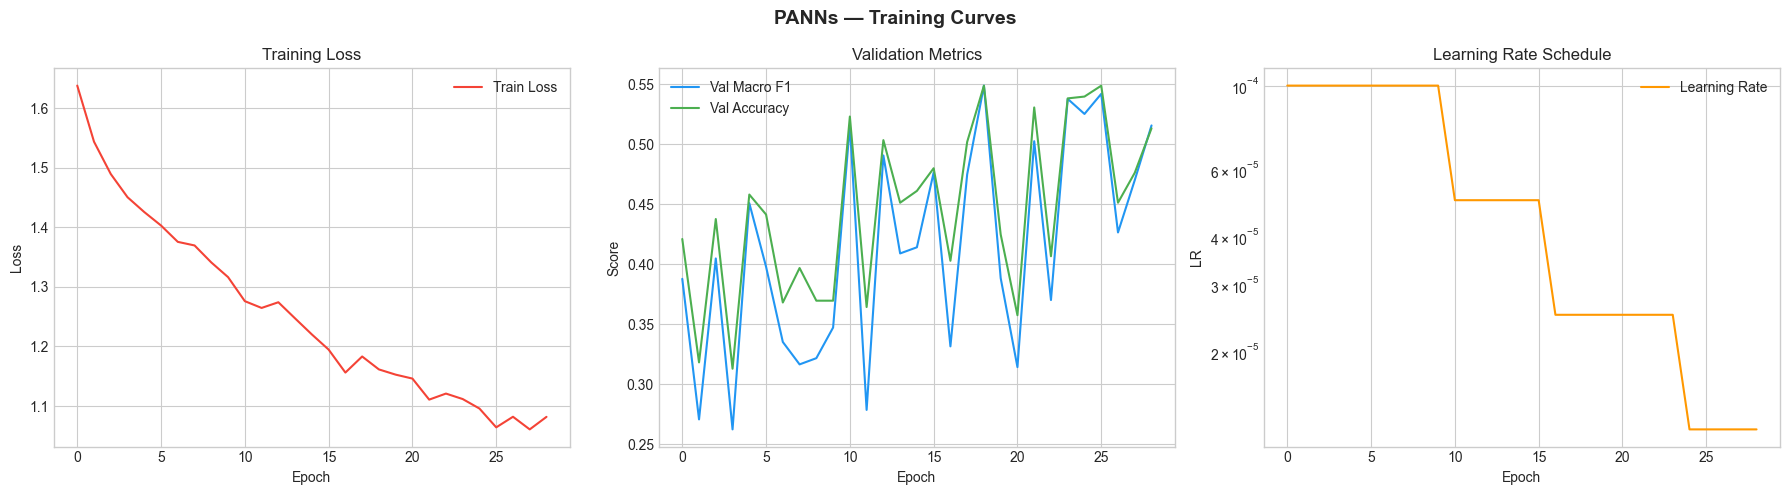

In [25]:
class PANNsCNN14(nn.Module):
    """
    PANNs CNN14 for transfer learning.

    Strategy:
    - Download Cnn14_16k_mAP=0.438.pth from the official PANNs repo
    - Place it in Config.CHECKPOINT_DIR
    - If checkpoint found: load pretrained weights, freeze backbone, fine-tune head
    - If not found: train CNN14-style architecture from scratch on LogMel

    Input: (B, 3, N_MELS, T) — normalized log-mel
    """

    CHECKPOINT_NAME = "Cnn14_16k_mAP=0.438.pth"

    def __init__(self, num_classes=6):
        super().__init__()
        self.is_pretrained = False
        ckpt_path = Config.CHECKPOINT_DIR / self.CHECKPOINT_NAME

        # Scratch CNN14-style backbone (works for both paths)
        self.backbone = nn.Sequential(
            nn.Conv2d(3,   64,  kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        if ckpt_path.exists():
            try:
                state = torch.load(ckpt_path, map_location="cpu")
                # PANNs checkpoint contains 'model' key
                pretrained_dict = state.get("model", state)
                # Load only matching keys (backbone layers)
                model_dict = self.backbone.state_dict()
                filtered   = {
                    k: v for k, v in pretrained_dict.items()
                    if k in model_dict and v.shape == model_dict[k].shape
                }
                model_dict.update(filtered)
                self.backbone.load_state_dict(model_dict)
                print(f"  [✓] PANNs pretrained weights loaded "
                      f"({len(filtered)}/{len(pretrained_dict)} layers matched)")
                self.is_pretrained = True
            except Exception as e:
                print(f"  ⚠️  PANNs checkpoint load failed: {e}")
                print("  ↳ Falling back to scratch CNN14")
        else:
            print(f"  ⚠️  Checkpoint not found: {ckpt_path}")
            print(f"  ↳ Download from: https://zenodo.org/record/3987831")
            print("  ↳ Running PANNs with scratch weights")

    def forward(self, x):
        return self.head(self.backbone(x))


print("="*60)
print("  PHASE 14 — PANNs CNN14")
print("="*60)

panns_model = PANNsCNN14(num_classes=len(Config.EMOTIONS))
print(f"  Pretrained: {panns_model.is_pretrained}")

model_panns, history_panns = train_model(
    panns_model,
    loaders["logmel"]["train"],
    loaders["logmel"]["val"],
    weight_tensor,
    lr        = 1e-4,
    name      = "PANNs",
    use_mixup = True,
)
plot_training_curves(history_panns, "PANNs")

  Evaluating PANNs:   0%|          | 0/42 [00:00<?, ?it/s]

  Evaluating PANNs:  21%|██▏       | 9/42 [00:00<00:00, 88.95it/s]

  Evaluating PANNs:  45%|████▌     | 19/42 [00:00<00:00, 90.29it/s]

  Evaluating PANNs:  69%|██████▉   | 29/42 [00:00<00:00, 91.69it/s]

  Evaluating PANNs:  93%|█████████▎| 39/42 [00:00<00:00, 94.33it/s]

  Evaluating PANNs: 100%|██████████| 42/42 [00:00<00:00, 92.75it/s]

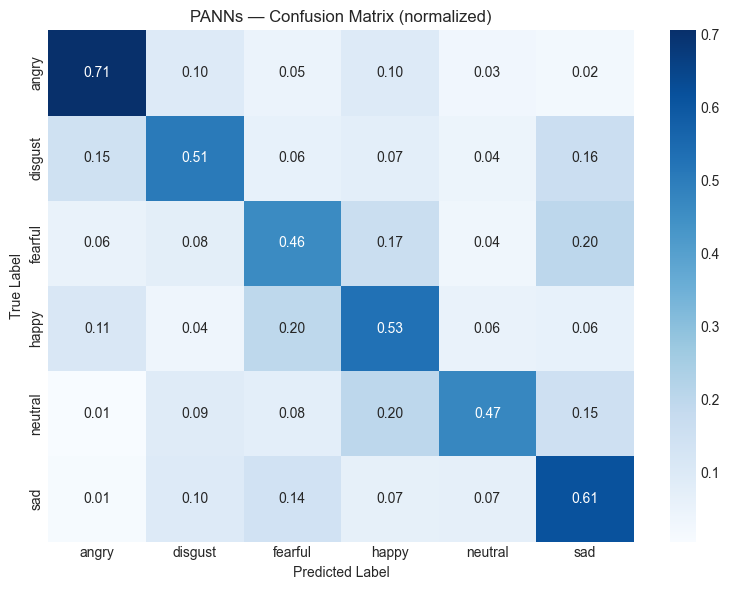


  Classification Report — PANNs
              precision    recall  f1-score   support

       angry       0.68      0.71      0.69       228
     disgust       0.57      0.51      0.54       228
     fearful       0.48      0.46      0.47       228
       happy       0.48      0.53      0.51       228
     neutral       0.62      0.47      0.54       184
         sad       0.52      0.61      0.56       228

    accuracy                           0.55      1324
   macro avg       0.56      0.55      0.55      1324
weighted avg       0.55      0.55      0.55      1324

  Metric                  Overall    RAVDESS    CREMA-D
  ----------------------------------------------------
  accuracy                 0.5514     0.5398     0.5531
  uar                      0.5488     0.5469     0.5509
  macro_f1                 0.5499     0.5284     0.5507
  weighted_f1              0.5504     0.5214     0.5512


In [26]:
results_panns = evaluate_model(
    "PANNs", model_panns,
    splits["test"], loaders["logmel"]["test"]
)

---
## Phase 15 — Wav2Vec2

In [27]:
if not TRANSFORMERS_AVAILABLE:
    print("⚠️  Transformers not available — skipping Wav2Vec2")
else:
    class Wav2Vec2_SER(nn.Module):
        """
        Fine-tuned facebook/wav2vec2-base for SER.
        - Feature extractor (CNN layers): frozen
        - First 8 transformer layers: frozen
        - Upper layers + classification head: trainable
        Input: raw waveform (B, T) at 16kHz
        """
        def __init__(self, num_classes=6, freeze_layers=8):
            super().__init__()
            self.model = Wav2Vec2ForSequenceClassification.from_pretrained(
                "facebook/wav2vec2-base",
                num_labels=num_classes,
                ignore_mismatched_sizes=True,
            )
            # Freeze CNN feature extractor
            self.model.wav2vec2.feature_extractor.requires_grad_(False)
            # Freeze lower transformer layers
            for i, layer in enumerate(self.model.wav2vec2.encoder.layers):
                for param in layer.parameters():
                    param.requires_grad = (i >= freeze_layers)

            trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
            total     = sum(p.numel() for p in self.parameters())
            print(f"  Wav2Vec2 params: {trainable:,} trainable / {total:,} total")

        def forward(self, input_values, attention_mask=None):
            return self.model(
                input_values=input_values,
                attention_mask=attention_mask
            ).logits


    print("="*60)
    print("  PHASE 15 — Wav2Vec2")
    print("="*60)

    model_w2v2, history_w2v2 = train_model(
        Wav2Vec2_SER(num_classes=len(Config.EMOTIONS), freeze_layers=8),
        loaders["waveform"]["train"],
        loaders["waveform"]["val"],
        weight_tensor,
        epochs    = 30,
        name      = "Wav2Vec2",
        is_w2v2   = True,
        use_mixup = False,
    )
    plot_training_curves(history_w2v2, "Wav2Vec2")

  PHASE 15 — Wav2Vec2


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 52744.39it/s]


[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Wav2Vec2 params: 33,666,694 trainable / 94,570,118 total


...

  Ep   8/30  Loss 0.8793  Val-F1 0.6509  Val-Acc 0.6523  LR 1.00e-05


  Ep   9/30  Loss 0.8491  Val-F1 0.6495  Val-Acc 0.6508  LR 1.00e-05


  Ep  10/30  Loss 0.8227  Val-F1 0.6724  Val-Acc 0.6727  LR 1.00e-05


  Ep  11/30  Loss 0.7985  Val-F1 0.6923  Val-Acc 0.6924  LR 1.00e-05


KeyboardInterrupt: 

In [ ]:
if TRANSFORMERS_AVAILABLE:
    results_w2v2 = evaluate_model(
        "Wav2Vec2", model_w2v2,
        splits["test"], loaders["waveform"]["test"],
        is_w2v2=True
    )

---
## Phase 16 — Final Benchmark Table

In [ ]:
all_results = {
    "SVM"              : results_svm,
    "CNN1D+Att+BiLSTM" : results_cnn1d,
    "CNN2D+Att+BiLSTM" : results_cnn2d,
    "PANNs"            : results_panns,
}
if TRANSFORMERS_AVAILABLE:
    all_results["Wav2Vec2"] = results_w2v2

# ── Build summary table ────────────────────────────────────────────────────
rows = []
for model_name, res in all_results.items():
    rows.append({
        "Model"           : model_name,
        "Accuracy"        : res.get("accuracy",    float("nan")),
        "UAR"             : res.get("uar",          float("nan")),
        "Macro F1"        : res.get("macro_f1",    float("nan")),
        "Weighted F1"     : res.get("weighted_f1", float("nan")),
        "RAVDESS Acc"     : res.get("ravdess_accuracy",  float("nan")),
        "CREMA-D Acc"     : res.get("crema_d_accuracy",  float("nan")),
    })

summary_df = pd.DataFrame(rows).set_index("Model")

print("\n" + "="*80)
print("  FINAL BENCHMARK RESULTS")
print("="*80)
print(summary_df.round(4).to_string())

# Save to CSV
summary_df.to_csv(Config.RESULTS_DIR / "final_benchmark.csv")
print(f"\n✅ Results saved to {Config.RESULTS_DIR / 'final_benchmark.csv'}")

In [ ]:
# ── Visual benchmark comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Final Benchmark — Model Comparison", fontsize=14, fontweight="bold")

metrics_to_plot = ["Accuracy", "UAR", "Macro F1", "Weighted F1"]
x = np.arange(len(summary_df))
width = 0.2
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    axes[0].bar(x + i*width, summary_df[metric], width,
                label=metric, color=color, alpha=0.85)

axes[0].set_title("Overall Metrics")
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(summary_df.index, rotation=20, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_ylabel("Score")

# Per-dataset accuracy
ds_metrics = ["RAVDESS Acc", "CREMA-D Acc"]
ds_colors  = ["#2196F3", "#FF9800"]
for i, (metric, color) in enumerate(zip(ds_metrics, ds_colors)):
    axes[1].bar(x + i*0.35, summary_df[metric], 0.35,
                label=metric, color=color, alpha=0.85)

axes[1].set_title("Per-Dataset Accuracy")
axes[1].set_xticks(x + 0.175)
axes[1].set_xticklabels(summary_df.index, rotation=20, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "final_benchmark.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Benchmark figure saved")

---
## Phase 17 — Discussion Template

### Results Analysis

*(Fill this in after running all phases)*

**Best Model:** `___`  
**Best Accuracy:** `___`  
**Best UAR:** `___`  

---

### Key Observations
1. **Classical vs Deep Learning:** ...
2. **RAVDESS vs CREMA-D performance gap:** ...
3. **Confusion patterns:** Which emotions are most confused and why?
4. **Impact of dataset imbalance:** CREMA-D is 87% of the data — does performance reflect this?

---

### Limitations
1. RAVDESS is acted speech; CREMA-D is elicited — acoustic conditions differ
2. CREMA-D constitutes 87% of the merged corpus — models may be biased toward its acoustic style
3. No demographic stratification (age, gender) in the split
4. 'calm' removed from RAVDESS — acoustically similar to 'neutral', which may affect neutral class performance

---

### Future Work
1. WavLM-large or HuBERT-large as stronger SSL baseline
2. Ensemble of CNN2D + Wav2Vec2
3. Demographic-aware evaluation (gender, age)
4. Real-world / in-the-wild speech evaluation

In [ ]:
print("="*60)
print("  PROJECT COMPLETE")
print("="*60)
print(f"  Figures   → {Config.FIGURES_DIR}")
print(f"  Results   → {Config.RESULTS_DIR}")
print(f"  Checkpoints → {Config.CHECKPOINT_DIR}")
print(f"  Cache     → {Config.CACHE_DIR}")
print("\n  Send results to continue analysis.")